# 01 – Eksploracyjna Analiza Danych (EDA)
**Dataset:** Car Prices Poland (Kaggle)  
**Cel:** Zapoznanie się z danymi, analiza rozkładów, wykrywanie anomalii i wartości brakujących.

## 1. Import bibliotek i wczytanie danych

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
from pathlib import Path
import os
PROJECT_ROOT = Path(os.getcwd())
# Jeśli CWD to notebooks/, cofnij się poziom wyżej
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_PATH    = str(PROJECT_ROOT / 'data' / 'raw' / 'Car_Prices_Poland_Kaggle.csv')
PROC_PATH    = str(PROJECT_ROOT / 'data' / 'processed') + os.sep
FIGURES_PATH = str(PROJECT_ROOT / 'reports' / 'figures') + os.sep
os.makedirs(PROC_PATH, exist_ok=True)
os.makedirs(FIGURES_PATH, exist_ok=True)
print('PROJECT_ROOT:', PROJECT_ROOT)
print('FIGURES_PATH:', FIGURES_PATH)

PROJECT_ROOT: C:\Uni\Projekt_DB_KB_PA
FIGURES_PATH: C:\Uni\Projekt_DB_KB_PA\reports\figures\


In [2]:
df = pd.read_csv(DATA_PATH, index_col=0)
print(f'Kształt danych: {df.shape}')
df.head(10)

Kształt danych: (117927, 10)


,mark,model,generation_name,year,mileage,vol_engine,fuel,city,province,price
0,opel,combo,gen-d-2011,2015,139568,1248,Diesel,Janki,Mazowieckie,35900
1,opel,combo,gen-d-2011,2018,31991,1499,Diesel,Katowice,Śląskie,78501
2,opel,combo,gen-d-2011,2015,278437,1598,Diesel,Brzeg,Opolskie,27000
3,opel,combo,gen-d-2011,2016,47600,1248,Diesel,Korfantów,Opolskie,30800
4,opel,combo,gen-d-2011,2014,103000,1400,CNG,Tarnowskie Góry,Śląskie,35900
5,opel,combo,gen-d-2011,2017,121203,1598,Diesel,Warszawa,Mazowieckie,51900
6,opel,combo,gen-d-2011,2017,119965,1248,Diesel,Wrocław,Dolnośląskie,44700
7,opel,combo,gen-d-2011,2016,201658,1248,Diesel,Lublin,Lubelskie,29000
8,opel,combo,gen-d-2011,2014,178666,1598,Diesel,Złotów,Wielkopolskie,28900
9,opel,combo,gen-d-2011,2015,113000,1248,Diesel,Strzyżew,Mazowieckie,34900


## 2. Podstawowe informacje o zbiorze danych

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 117927 entries, 0 to 117926
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   mark             117927 non-null  str  
 1   model            117927 non-null  str  
 2   generation_name  87842 non-null   str  
 3   year             117927 non-null  int64
 4   mileage          117927 non-null  int64
 5   vol_engine       117927 non-null  int64
 6   fuel             117927 non-null  str  
 7   city             117927 non-null  str  
 8   province         117927 non-null  str  
 9   price            117927 non-null  int64
dtypes: int64(4), str(6)
memory usage: 9.0 MB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
mark,117927,23,audi,12031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,117927,328,astra,3331,NaN,NaN,NaN,NaN,NaN,NaN,NaN
generation_name,87842,364,gen-8p-2003-2012,1567,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,117927.0,NaN,NaN,NaN,2012.925259,5.690135,1945.0,2009.0,2013.0,2018.0,2022.0
mileage,117927.0,NaN,NaN,NaN,140976.786147,92369.357269,0.0,67000.0,146269.0,203000.0,2800000.0
vol_engine,117927.0,NaN,NaN,NaN,1812.057782,643.613438,0.0,1461.0,1796.0,1995.0,7600.0
fuel,117927,6,Gasoline,61597,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,117927,4427,Warszawa,7972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
province,117927,23,Mazowieckie,22219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,117927.0,NaN,NaN,NaN,70299.884793,84824.577791,500.0,21000.0,41900.0,83600.0,2399900.0


## 3. Brakujące wartości

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Brakujące': missing, '% brakujących': missing_pct})
print(missing_df[missing_df['Brakujące'] > 0])

                 Brakujące  % brakujących
generation_name      30085          25.51


## 4. Rozkłady zmiennych numerycznych

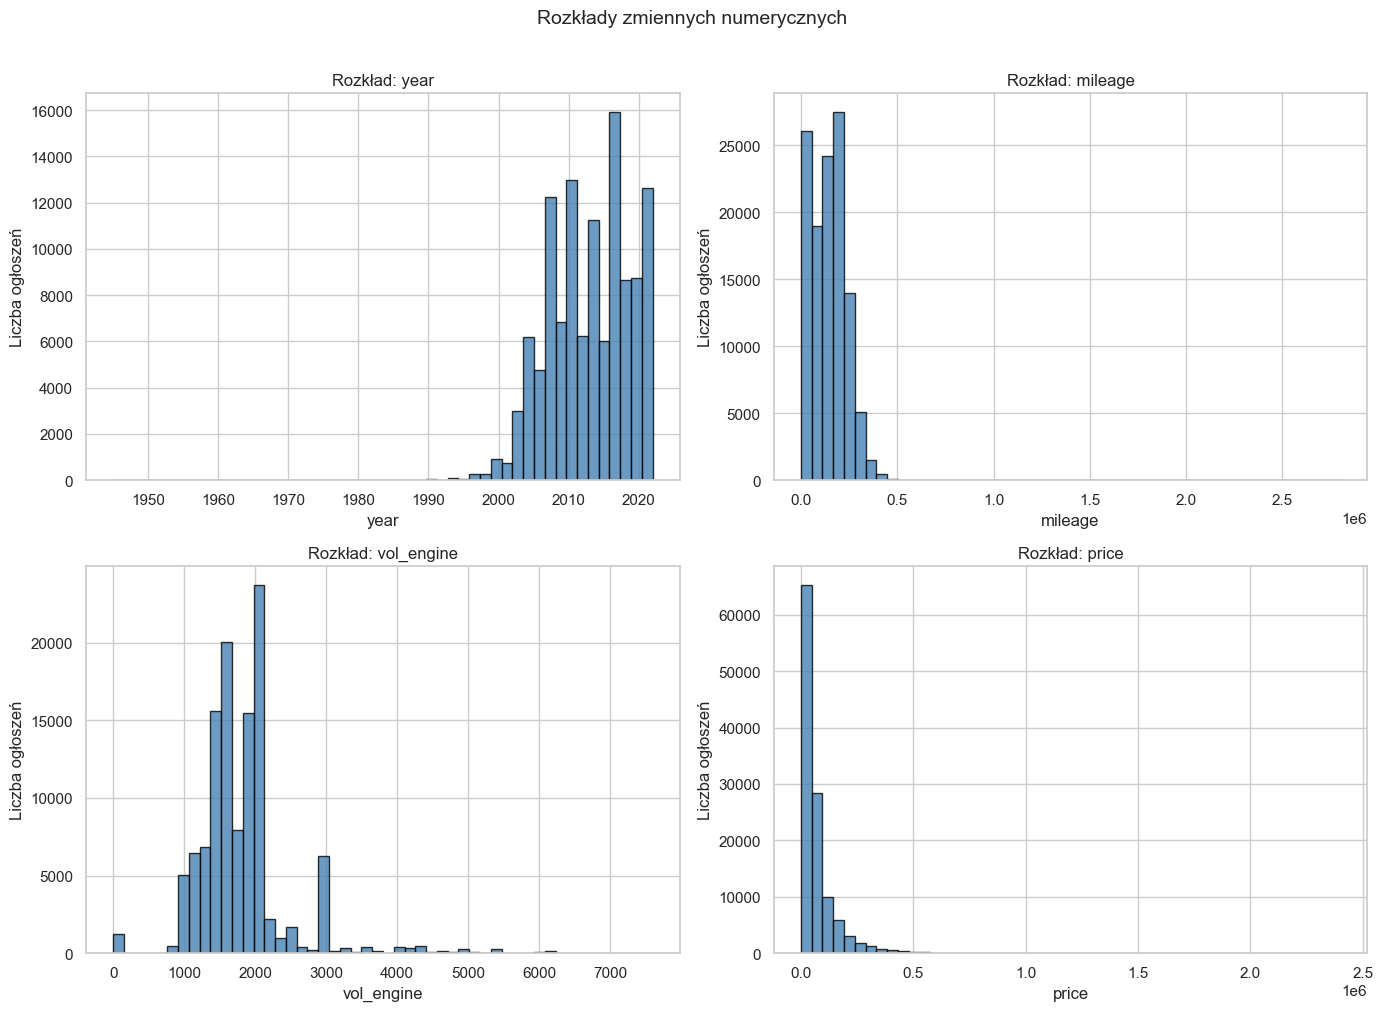

In [6]:
num_cols = ['year', 'mileage', 'vol_engine', 'price']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=50, edgecolor='black', color='steelblue', alpha=0.8)
    axes[i].set_title(f'Rozkład: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Liczba ogłoszeń')
plt.suptitle('Rozkłady zmiennych numerycznych', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_PATH + '01_distributions_numeric.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Rozkład ceny – transformacja logarytmiczna

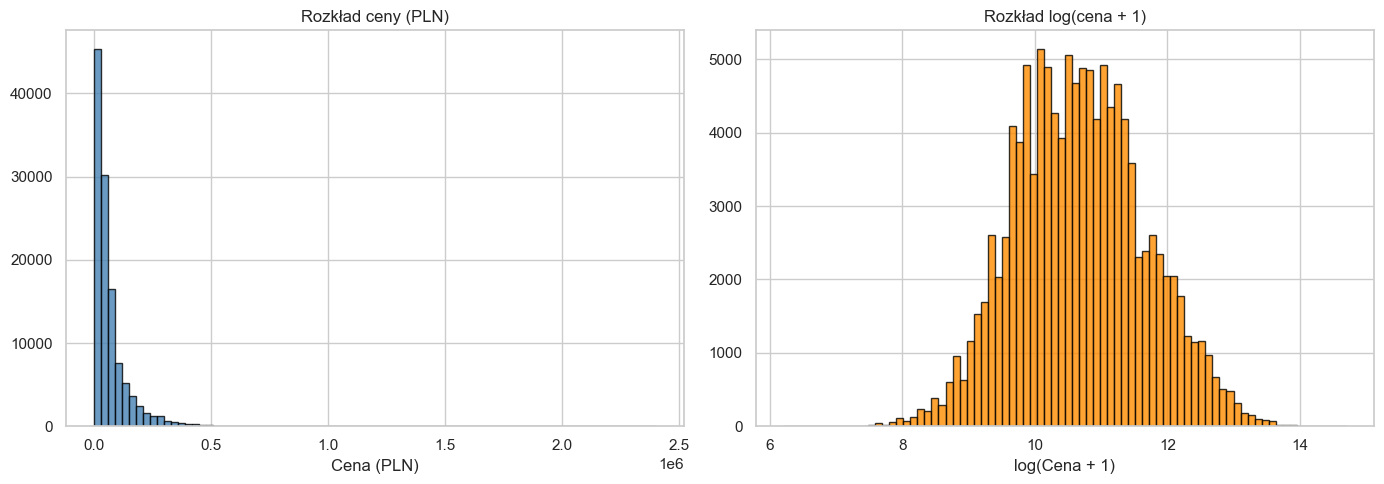

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['price'].dropna(), bins=80, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Rozkład ceny (PLN)')
axes[0].set_xlabel('Cena (PLN)')
axes[1].hist(np.log1p(df['price'].dropna()), bins=80, color='darkorange', edgecolor='black', alpha=0.8)
axes[1].set_title('Rozkład log(cena + 1)')
axes[1].set_xlabel('log(Cena + 1)')
plt.tight_layout()
plt.savefig(FIGURES_PATH + '01_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Zmienne kategoryczne

In [8]:
cat_cols = ['mark', 'fuel', 'province']
for col in cat_cols:
    print(f'\n--- {col} --- ({df[col].nunique()} unikalnych wartości)')
    print(df[col].value_counts().head(15))


--- mark --- (23 unikalnych wartości)
mark
audi             12031
opel             11914
bmw              11070
volkswagen       10848
ford              9664
mercedes-benz     7136
renault           6976
skoda             5888
toyota            5120
peugeot           5056
volvo             4384
hyundai           4032
kia               3744
nissan            3072
fiat              2880
Name: count, dtype: int64

--- fuel --- (6 unikalnych wartości)
fuel
Gasoline    61597
Diesel      48476
LPG          4301
Hybrid       2621
Electric      885
CNG            47
Name: count, dtype: int64

--- province --- (23 unikalnych wartości)
province
Mazowieckie            22219
Śląskie                16706
Wielkopolskie          14016
Małopolskie             9756
Dolnośląskie            8838
Łódzkie                 7884
Pomorskie               7605
Kujawsko-pomorskie      5371
Lubelskie               4740
Zachodniopomorskie      3963
Podkarpackie            3553
Świętokrzyskie          3337
Warmińsk

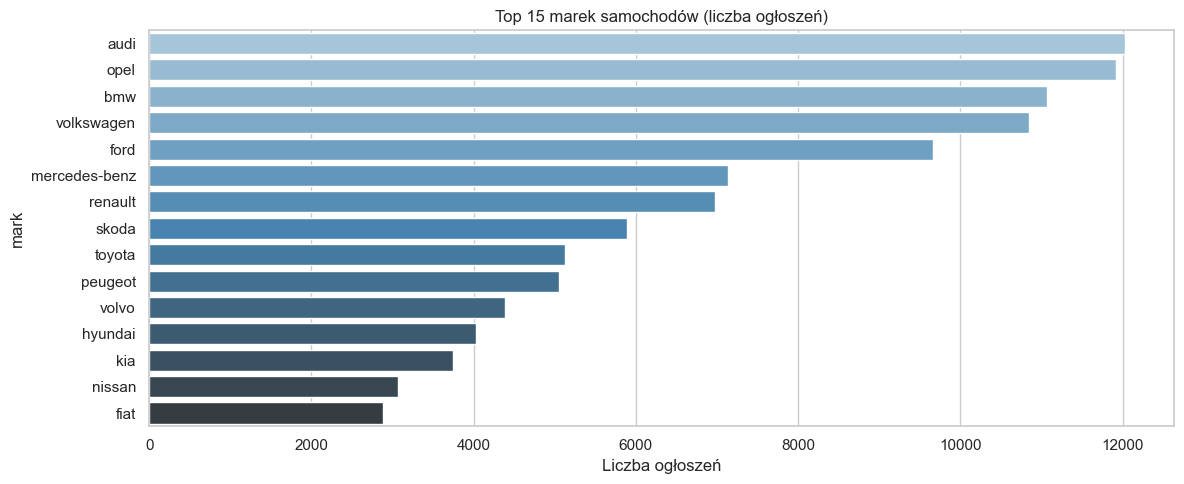

In [9]:
top_marks = df['mark'].value_counts().head(15)
plt.figure(figsize=(12, 5))
sns.barplot(x=top_marks.values, y=top_marks.index, palette='Blues_d')
plt.title('Top 15 marek samochodów (liczba ogłoszeń)')
plt.xlabel('Liczba ogłoszeń')
plt.tight_layout()
plt.savefig(FIGURES_PATH + '01_top_marks.png', dpi=150, bbox_inches='tight')
plt.show()

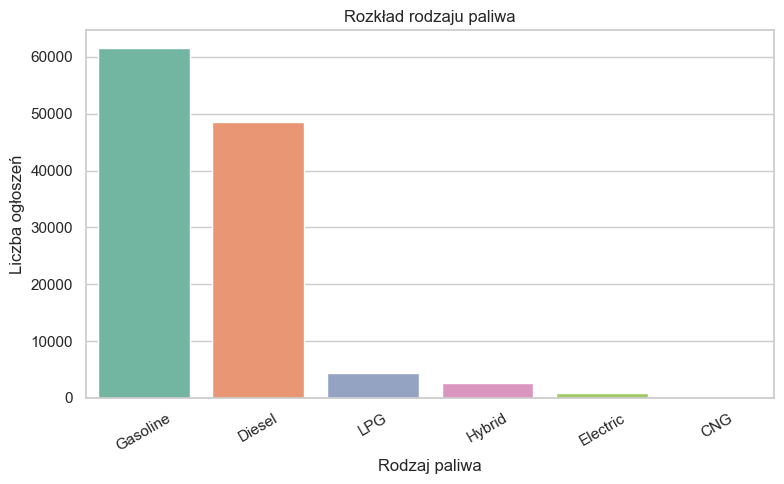

In [10]:
fuel_counts = df['fuel'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=fuel_counts.index, y=fuel_counts.values, palette='Set2')
plt.title('Rozkład rodzaju paliwa')
plt.xlabel('Rodzaj paliwa')
plt.ylabel('Liczba ogłoszeń')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_PATH + '01_fuel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Cena według rodzaju paliwa

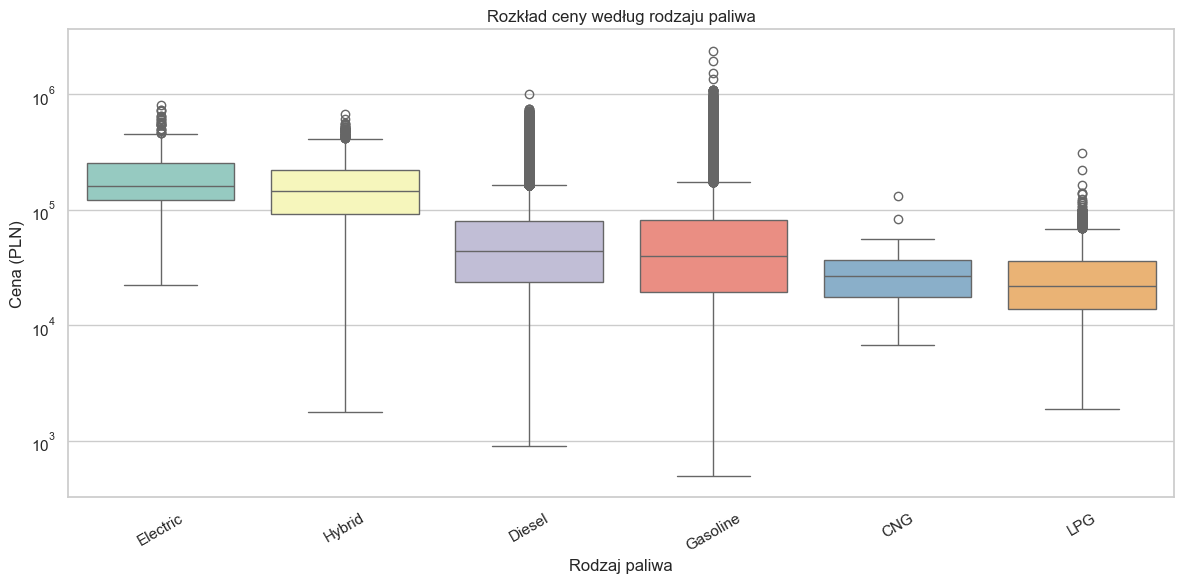

In [11]:
plt.figure(figsize=(12, 6))
order = df.groupby('fuel')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='fuel', y='price', order=order, palette='Set3')
plt.title('Rozkład ceny według rodzaju paliwa')
plt.xlabel('Rodzaj paliwa')
plt.ylabel('Cena (PLN)')
plt.yscale('log')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_PATH + '01_price_by_fuel.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Cena według roku produkcji

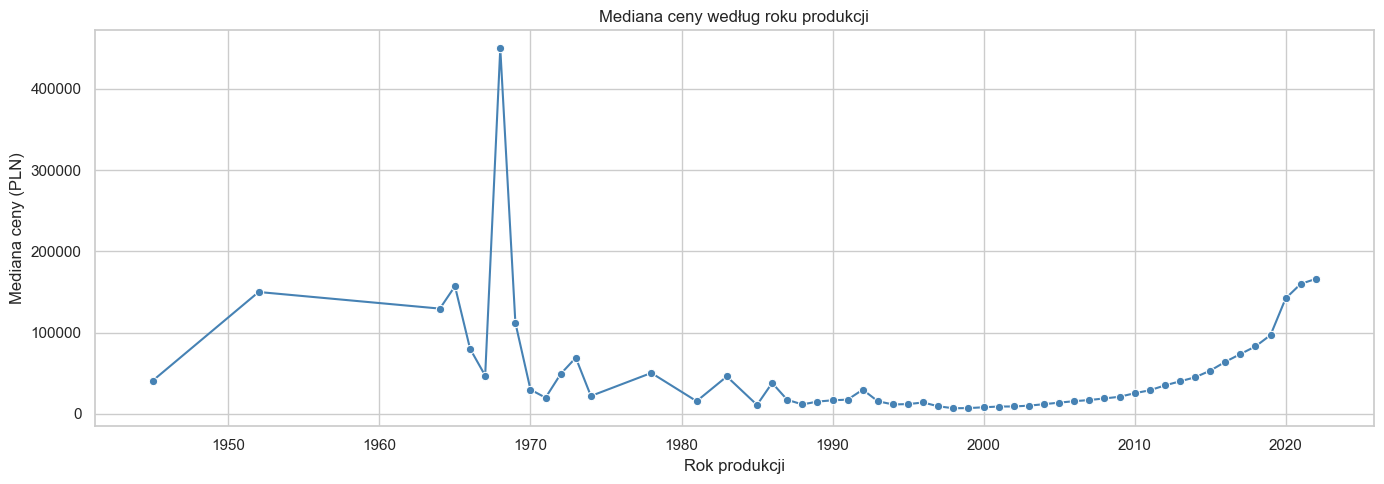

In [12]:
year_price = df.groupby('year')['price'].median().reset_index()
plt.figure(figsize=(14, 5))
sns.lineplot(data=year_price, x='year', y='price', marker='o', color='steelblue')
plt.title('Mediana ceny według roku produkcji')
plt.xlabel('Rok produkcji')
plt.ylabel('Mediana ceny (PLN)')
plt.tight_layout()
plt.savefig(FIGURES_PATH + '01_price_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Cena vs. przebieg

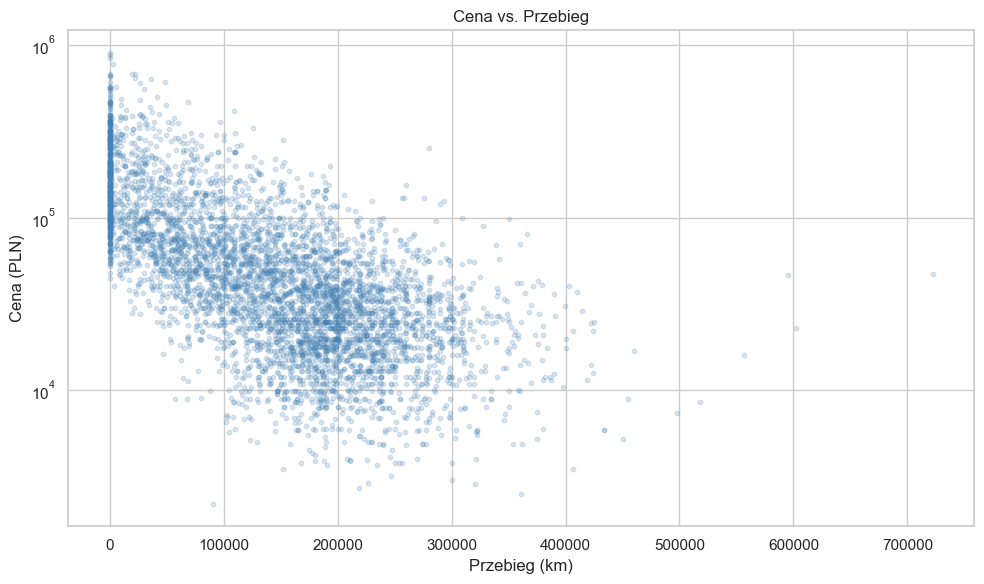

In [13]:
sample = df.dropna(subset=['mileage', 'price']).sample(min(5000, len(df)), random_state=42)
plt.figure(figsize=(10, 6))
plt.scatter(sample['mileage'], sample['price'], alpha=0.2, s=10, color='steelblue')
plt.title('Cena vs. Przebieg')
plt.xlabel('Przebieg (km)')
plt.ylabel('Cena (PLN)')
plt.yscale('log')
plt.tight_layout()
plt.savefig(FIGURES_PATH + '01_price_vs_mileage.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Heatmapa korelacji zmiennych numerycznych

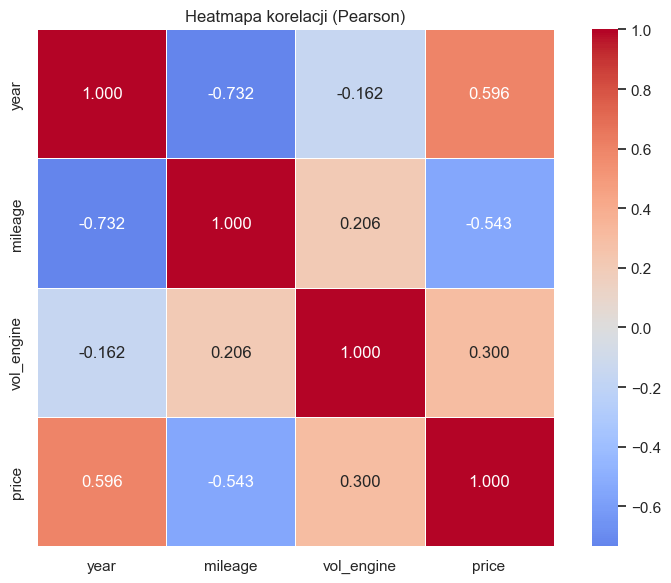


Korelacje z ceną:
price         1.000000
year          0.596181
vol_engine    0.299669
mileage      -0.542808
Name: price, dtype: float64


In [14]:
corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Heatmapa korelacji (Pearson)')
plt.tight_layout()
plt.savefig(FIGURES_PATH + '01_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nKorelacje z ceną:')
print(corr['price'].sort_values(ascending=False))

## 11. Top 15 marek – mediana ceny

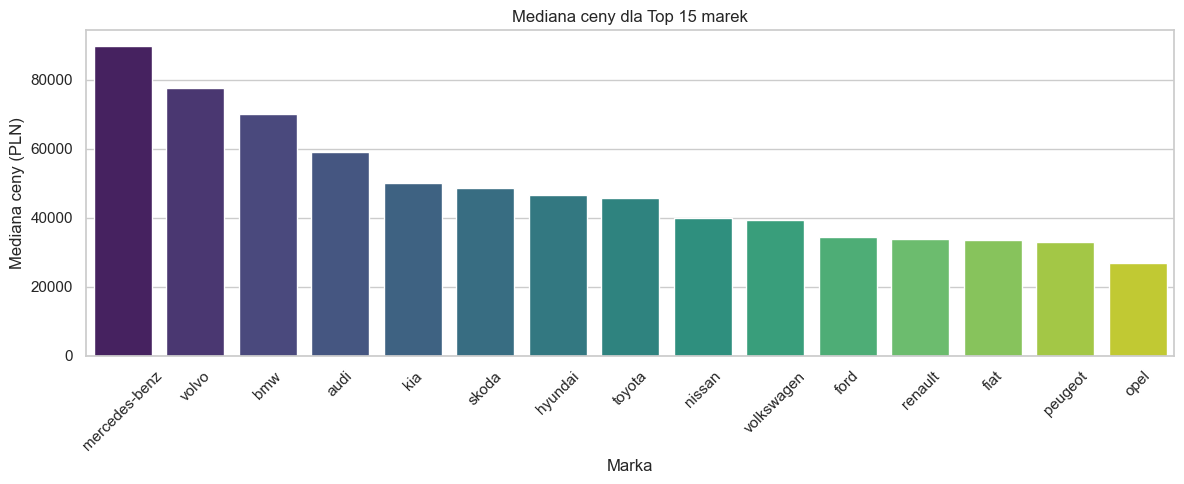

In [15]:
top15 = df['mark'].value_counts().head(15).index
mark_price = (df[df['mark'].isin(top15)]
              .groupby('mark')['price']
              .median()
              .sort_values(ascending=False))
plt.figure(figsize=(12, 5))
sns.barplot(x=mark_price.index, y=mark_price.values, palette='viridis')
plt.title('Mediana ceny dla Top 15 marek')
plt.xlabel('Marka')
plt.ylabel('Mediana ceny (PLN)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_PATH + '01_median_price_by_mark.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Cena według województwa

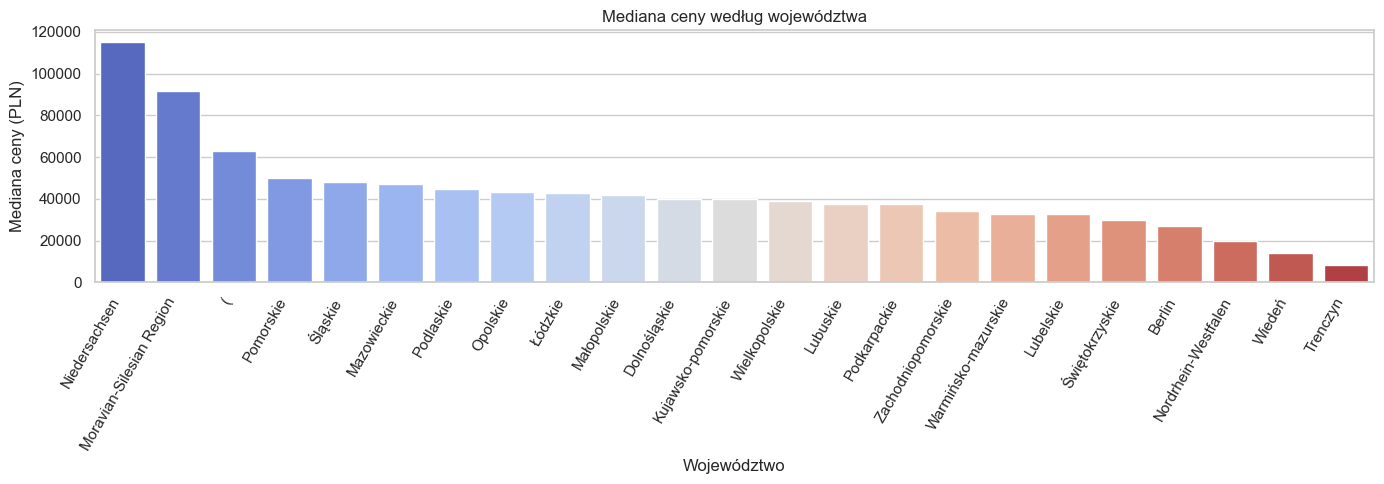

In [16]:
province_price = (df.groupby('province')['price']
                  .median()
                  .sort_values(ascending=False)
                  .reset_index())
plt.figure(figsize=(14, 5))
sns.barplot(data=province_price, x='province', y='price', palette='coolwarm')
plt.title('Mediana ceny według województwa')
plt.xlabel('Województwo')
plt.ylabel('Mediana ceny (PLN)')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_PATH + '01_price_by_province.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Wnioski z EDA

- Zbiór danych zawiera ogłoszenia sprzedaży samochodów z całej Polski (styczeń 2022).
- Cena jest **prawostronnie skośna** – transformacja `log` przybliża ją do rozkładu normalnego.
- **Rok produkcji** wykazuje silną dodatnią korelację z ceną; **przebieg** – ujemną.
- Pojemność silnika (`vol_engine`) ma umiarkowaną korelację z ceną.
- Samochody elektryczne i hybrydowe mają wyraźnie wyższe ceny mediany.
- Dane wymagają czyszczenia – patrz notebook `02_preprocessing.ipynb`.